# eDNA monitoring of riverine fish communities
The analysis is based on the worksheet **Supplementary Table 1**.

In [1]:
# Libraries used for data analysis and figures
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Importing the excel File and sheet included.
file_name = "Kaur_2026_Riverine_Fish_eDNA_Supplementary_Data.XLSX"
# Load Supplementary Table 1 and use header=1 uses the second Excel row as the column headings
data = pd.read_excel(
    file_name,
    sheet_name="Supplementary Table 1",
    header=1
)
print("Number of studies:", len(data))
print("Number of variables:", len(data.columns))
data.head()

Number of studies: 58
Number of variables: 45


,Study ID,First Author,Publish Year,Continent,River-system category,Examined river length (km),Reported discharge (m³/s),Reported eDNA detection distance (km),Interpreted turbidity category,Sampling Year/period,...,Bioinformatic pipeline (Std),Sequence filtering and taxonomic assignment criteria,Reference database (Std),Conventional monitoring method,Number of paired comparison sites (avg),eDNA-detected richness (avg),Conventionally detected richness (avg),eDNA/conventional richness ratio (avg),Shared species/taxa (avg),Higher-richness method
0,#01,Antognazza,2021,Europe,Large river + tributary,130;354,_,_,Moderate - High,2017-18 (May- June),...,DADA2-based pipeline,76% identity (blast filtering step),NCBI + custom,Electrofishing + fyke + seine,4,17.5,17,1.15,6,Yes
1,#02,Antognazza,2021,Europe,Large river + tributary,130;354,3-21.3(River Teme); 29.3- 83.3 (River Severn),_,Moderate - High,2018-19,...,_,_,_,_,_,_,_,_,_,_
2,#03,Astorg,2025,North America,River-lake connected system,_,_,_,High,2019; 2022,...,Barque / metaBEAT-based pipeline,97% minimum similarity threshold; reads <0.001...,NCBI / GenBank / EMBL,Electrofishing,19,36,19,1.89,15,Yes
3,#04,Baudry,2025,North America,Small River/Streams,_,_,_,Moderate - High,2023,...,DADA2-based pipeline,RDP classifier cutoff = 75; ASVs <10 reads and...,Custom / regional DB,Electrofishing,14,4.935,2.98,1.85,_,Yes
4,#05,Beridze,2023,Asia,Large river,90,424 m³/s (13.37 km³/year),_,High,2018-19,...,NatureMetrics,Reads mapped at 97%; species-level cut-off 97%...,NCBI + custom,Historical records ( Kuljanishvili et al. (202...,_,34,44,0.77,25,Yes


The dataset was cleaned before analysis. Empty rows and columns were removed, column names were standardised, and spreadsheet placeholders were converted to missing values.

In [3]:
# Prepare the standardised dataset for analysis

study_data = data.replace("_", np.nan).copy()

study_data.columns = (
    study_data.columns
    .str.strip()
    .str.replace("\n", " ", regex=False)
)

study_data.head()

,Study ID,First Author,Publish Year,Continent,River-system category,Examined river length (km),Reported discharge (m³/s),Reported eDNA detection distance (km),Interpreted turbidity category,Sampling Year/period,...,Bioinformatic pipeline (Std),Sequence filtering and taxonomic assignment criteria,Reference database (Std),Conventional monitoring method,Number of paired comparison sites (avg),eDNA-detected richness (avg),Conventionally detected richness (avg),eDNA/conventional richness ratio (avg),Shared species/taxa (avg),Higher-richness method
0,#01,Antognazza,2021,Europe,Large river + tributary,130;354,NaN,NaN,Moderate - High,2017-18 (May- June),...,DADA2-based pipeline,76% identity (blast filtering step),NCBI + custom,Electrofishing + fyke + seine,4.0,17.500,17.00,1.15,6.0,Yes
1,#02,Antognazza,2021,Europe,Large river + tributary,130;354,3-21.3(River Teme); 29.3- 83.3 (River Severn),NaN,Moderate - High,2018-19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,#03,Astorg,2025,North America,River-lake connected system,NaN,NaN,NaN,High,2019; 2022,...,Barque / metaBEAT-based pipeline,97% minimum similarity threshold; reads <0.001...,NCBI / GenBank / EMBL,Electrofishing,19.0,36.000,19.00,1.89,15.0,Yes
3,#04,Baudry,2025,North America,Small River/Streams,NaN,NaN,NaN,Moderate - High,2023,...,DADA2-based pipeline,RDP classifier cutoff = 75; ASVs <10 reads and...,Custom / regional DB,Electrofishing,14.0,4.935,2.98,1.85,NaN,Yes
4,#05,Beridze,2023,Asia,Large river,90,424 m³/s (13.37 km³/year),NaN,High,2018-19,...,NatureMetrics,Reads mapped at 97%; species-level cut-off 97%...,NCBI + custom,Historical records ( Kuljanishvili et al. (202...,NaN,34.000,44.00,0.77,25.0,Yes


In [4]:
# variable names available in the dataset
for column in study_data.columns:
    print(column)

Study ID
First Author
Publish Year
Continent
River-system category
Examined river length (km)
Reported discharge (m³/s)
Reported eDNA detection distance (km)
Interpreted turbidity category
Sampling Year/period
Site-selection design
Replicates per site (avg)
Volume per sample (L) (avg)
Total filtered volume per site(L) (avg)
Number of sampling sites (avg)
Sampling platform
Water-collection method
Replication type
Filtration location
Time from collection to filtration (h)
Filter format
Filter material
Pre-filtration preservation
Filter pore size (µm)
Min Pore (µm)
Max Pore (µm)
Pre-filter / Sequential
Post-filtration preservation method
DNA extraction kit (Std)
Target marker gene (Std)
Primer system / assay (Std)
Amplicon length (bp)
Molecular detection approach (Std)
Sequencing platform (Std)
ASV/OTU method (Std)
Bioinformatic pipeline (Std)
Sequence filtering and taxonomic assignment criteria
Reference database (Std)
Conventional monitoring method
Number of paired comparison sites (avg

#### Figure 2: Temporal distribution of included riverine fish eDNA studies by publication year.
The number of included studies published each year was summarised to show how research on riverine fish eDNA monitoring developed over time.

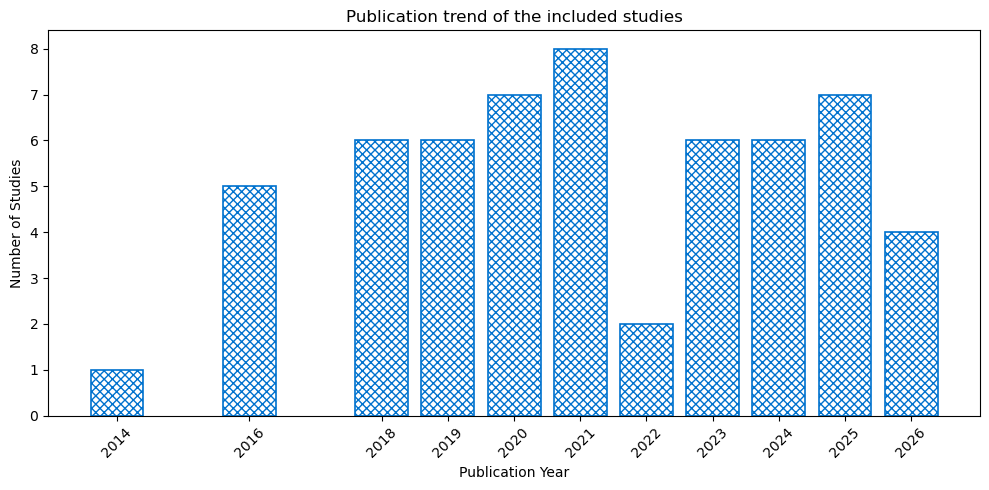

In [5]:
# Count the number of studies published each year
studies_per_year = (
    study_data["Publish Year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)
studies_per_year
# Figure 2
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    studies_per_year.index,
    studies_per_year.values,
    facecolor="white",
    edgecolor="#0072CE",
    linewidth=1.2,
    hatch="xxxx"
)
ax.set_xlabel("Publication Year")
ax.set_ylabel("Number of Studies")
ax.set_title("Publication trend of the included studies")
ax.set_xticks(studies_per_year.index)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(
    "Figure 2: Temporal distribution of included riverine fish eDNA studies by publication year.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Figure 3: Continental representation of reviewed riverine fish eDNA studies.

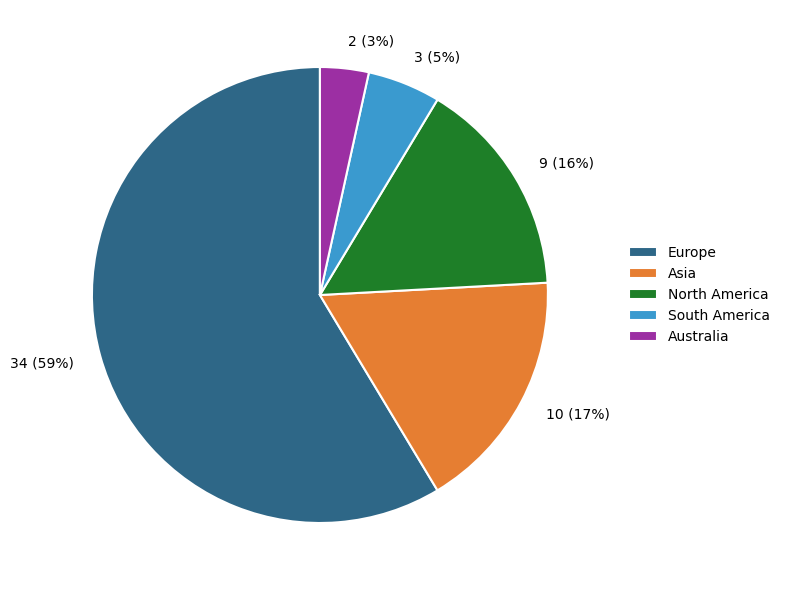

In [6]:
# Count studies by continent
studies_by_continent = study_data["Continent"].dropna().value_counts()
total = studies_by_continent.sum()
slice_labels = [
    f"{count} ({count / total:.0%})"
    for count in studies_by_continent.values
]
colours = [
    "#2E6787",   # Europe
    "#E67E32",   # Asia
    "#1E7F28",   # North America
    "#3A9ACF",   # South America
    "#9C2FA3"    # Australia
]
# Figure 3: Continental representation of reviewed riverine fish eDNA studies
fig, ax = plt.subplots(figsize=(10, 6))
wedges, texts = ax.pie(
    studies_by_continent.values,
    labels=slice_labels,
    colors=colours,
    startangle=90,
    labeldistance=1.12,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1.5
    },
    textprops={
        "fontsize": 10
    }
)
# legends
ax.legend(
    wedges,
    studies_by_continent.index,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(
    "Figure 3: Continental representation of reviewed riverine fish eDNA studies.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Figure 4: Cumulative use of molecular detection approaches in reviewed riverine fish eDNA studies.
The cumulative number of studies using metabarcoding and species-specific PCR was examined across publication years. Studies applying both approaches were counted in both categories.

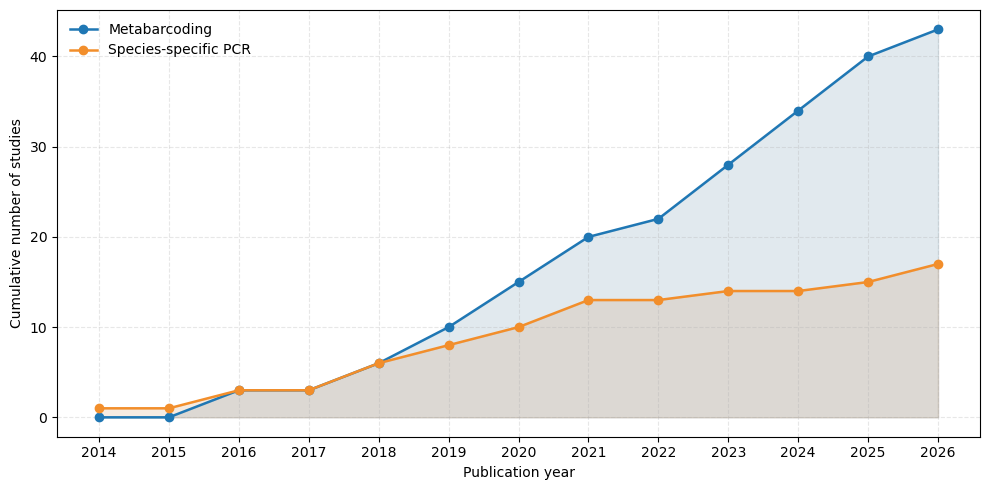

In [7]:
approach_data = study_data[
    ["Publish Year", "Molecular detection approach (Std)"]
].dropna().copy()

approach_data["Publish Year"] = approach_data["Publish Year"].astype(int)
years = range(
    approach_data["Publish Year"].min(),
    approach_data["Publish Year"].max() + 1
)

# Count studies using metabarcoding
metabarcoding = (
    approach_data[
        approach_data["Molecular detection approach (Std)"]
        .isin(["Metabarcoding", "Both"])
    ]["Publish Year"]
    .value_counts()
    .reindex(years, fill_value=0)
    .sort_index()
    .cumsum()
)

# Count studies using species-specific PCR
species_specific = (
    approach_data[
        approach_data["Molecular detection approach (Std)"]
        .isin([
            "Species specific (qPCR/ddPCR/Endpoint PCR)",
            "Both"
        ])
    ]["Publish Year"]
    .value_counts()
    .reindex(years, fill_value=0)
    .sort_index()
    .cumsum()
)

# Figure 4: Cumulative use of molecular detection approaches
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    years,
    metabarcoding,
    marker="o",
    linewidth=1.8,
    color="#1F77B4",
    label="Metabarcoding"
)

ax.plot(
    years,
    species_specific,
    marker="o",
    linewidth=1.8,
    color="#F28E2B",
    label="Species-specific PCR"
)

ax.fill_between(years, metabarcoding, color="#3B6F8F", alpha=0.15)
ax.fill_between(years, species_specific, color="#C47C3C", alpha=0.15)

ax.set_xlabel("Publication year")
ax.set_ylabel("Cumulative number of studies")
ax.set_xticks(list(years))

ax.grid(axis="both", linestyle="--", alpha=0.3)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig(
    "Figure 4: Cumulative use of molecular detection approaches.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Figure 5: eDNA-to-conventional richness ratios across site-selection designs.
The ratio between eDNA-detected richness and conventionally detected richness was compared among longitudinal, spatially distributed and hybrid sampling designs.

Kruskal–Wallis H = 1.88
p = 0.3910
n = 32

Group sizes:
Design
Spatially distributed    16
Longitudinal             14
Hybrid                    2
Name: count, dtype: int64

Medians:
Design
Hybrid                   0.935
Longitudinal             1.355
Spatially distributed    1.225
Name: Richness ratio, dtype: float64


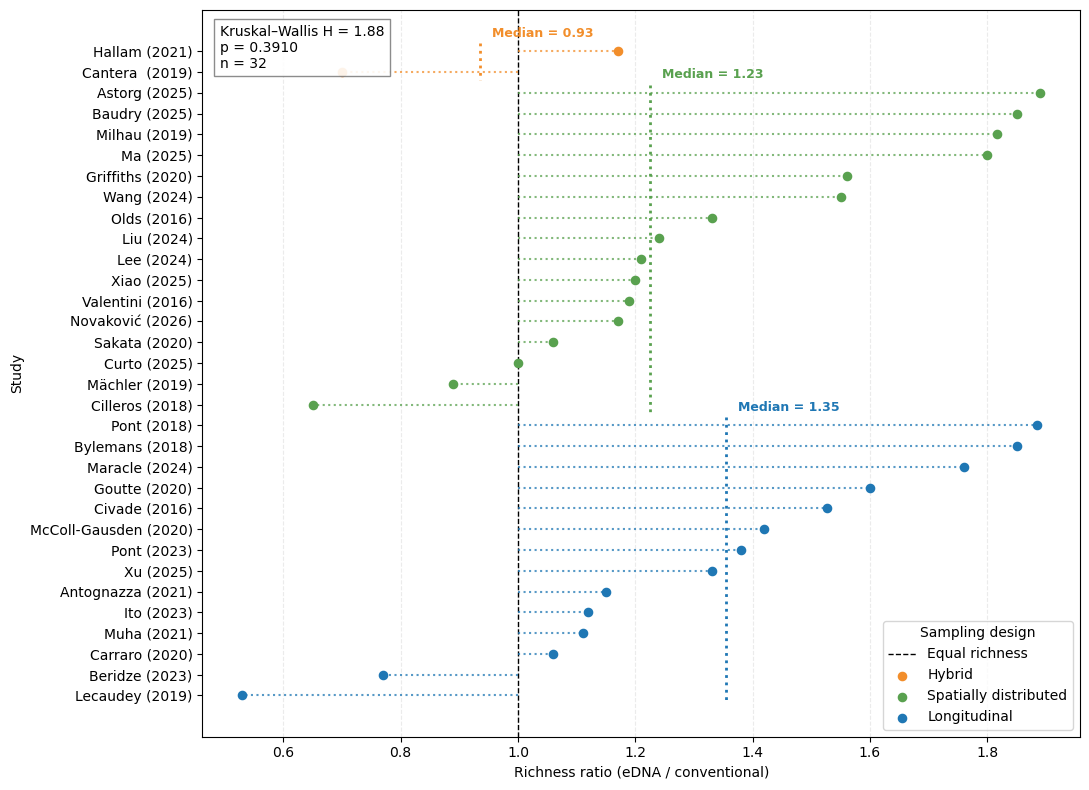

In [8]:
# Prepare data
richness = (
    study_data[
        [
            "First Author",
            "Publish Year",
            "Site-selection design",
            "eDNA/conventional richness ratio (avg)"
        ]
    ]
    .dropna()
    .rename(
        columns={
            "eDNA/conventional richness ratio (avg)": "Richness ratio"
        }
    )
)

# Shorten design names

richness["Design"] = richness["Site-selection design"].replace(
    {
        "Longitudinal river-gradient sampling": "Longitudinal",
        "Spatially distributed fixed-site sampling": "Spatially distributed",
        "Hybrid longitudinal–fixed-site sampling": "Hybrid"
    }
)

# Exclude the extreme richness ratio of 11.11
richness = richness[richness["Richness ratio"] < 5].copy()

design_order = [
    "Hybrid",
    "Spatially distributed",
    "Longitudinal"
]

# Kruskal–Wallis test
groups = [
    richness.loc[
        richness["Design"] == design,
        "Richness ratio"
    ]
    for design in design_order
]

H, p = stats.kruskal(*groups)

print(f"Kruskal–Wallis H = {H:.2f}")
print(f"p = {p:.4f}")
print(f"n = {len(richness)}")
print("\nGroup sizes:")
print(richness["Design"].value_counts())
print("\nMedians:")
print(richness.groupby("Design")["Richness ratio"].median())

# Prepare study labels and plotting order
richness["Study"] = (
    richness["First Author"]
    + " ("
    + richness["Publish Year"].astype(int).astype(str)
    + ")"
)

richness["Design"] = pd.Categorical(
    richness["Design"],
    categories=design_order,
    ordered=True
)

plot_data = (
    richness
    .sort_values(
        ["Design", "Richness ratio"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

plot_data["y"] = range(len(plot_data))

colours = {
    "Hybrid": "#F28E2B",
    "Spatially distributed": "#59A14F",
    "Longitudinal": "#1F77B4"
}

# Create figure
fig, ax = plt.subplots(figsize=(11, 8))

ax.axvline(
    1,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Equal richness"
)

for design in design_order:

    group = plot_data[plot_data["Design"] == design]
    colour = colours[design]
    median = group["Richness ratio"].median()

    ax.hlines(
        group["y"],
        1,
        group["Richness ratio"],
        color=colour,
        linestyle=":",
        linewidth=1.5,
        alpha=0.75
    )

    ax.scatter(
        group["Richness ratio"],
        group["y"],
        color=colour,
        s=35,
        label=design,
        zorder=3
    )

    ax.vlines(
        median,
        group["y"].min() - 0.4,
        group["y"].max() + 0.4,
        color=colour,
        linestyle=":",
        linewidth=2
    )

    ax.text(
        median + 0.02,
        group["y"].min() - 0.7,
        f"Median = {median:.2f}",
        color=colour,
        fontweight="bold",
        fontsize=9
    )

ax.set_yticks(plot_data["y"])
ax.set_yticklabels(plot_data["Study"])
ax.invert_yaxis()

ax.set_xlabel("Richness ratio (eDNA / conventional)")
ax.set_ylabel("Study")

ax.text(
    0.02,
    0.98,
    (
        f"Kruskal–Wallis H = {H:.2f}\n"
        f"p = {p:.4f}\n"
        f"n = {len(plot_data)}"
    ),
    transform=ax.transAxes,
    va="top",
    bbox={
        "facecolor": "white",
        "edgecolor": "grey",
        "alpha": 0.9
    }
)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.legend(
    title="Sampling design",
    loc="lower right",
    frameon=True
)

plt.tight_layout()

plt.savefig(
    "Figure 5: eDNA-to-conventional species-richness ratios across spatial sampling-design categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Figure 6: Relationship between river discharge and reported downstream eDNA scale.
The relationship between river discharge and the reported downstream eDNA spatial distance was examined using log10-transformed study-level values.The dashed line represents the ordinary least-squares regression, and the shaded area shows its 95% confidence interval.
Because the reviewed studies differed in sampling design and in how downstream distance was defined, the analysis was treated as exploratory rather than as a predictive transport model.

In [9]:
discharge_data = study_data[
    [
        "Reported discharge (m³/s)",
        "Reported eDNA detection distance (km)"
    ]
].copy()

discharge_data.columns = ["Discharge", "Distance"]

# Convert the columns to numbers and remove missing values
discharge_data["Discharge"] = pd.to_numeric(
    discharge_data["Discharge"],
    errors="coerce"
)

discharge_data["Distance"] = pd.to_numeric(
    discharge_data["Distance"],
    errors="coerce"
)

discharge_data = discharge_data.dropna()

# Log10 transformation
discharge_data["logQ"] = np.log10(discharge_data["Discharge"])
discharge_data["logDistance"] = np.log10(discharge_data["Distance"])

# Discharge categories
discharge_data["Category"] = pd.cut(
    discharge_data["Discharge"],
    bins=[0, 1, 10, np.inf],
    labels=["Low discharge", "Medium discharge", "High discharge"]
)

# Regression and correlation
regression = stats.linregress(
    discharge_data["logQ"],
    discharge_data["logDistance"]
)

rho, spearman_p = stats.spearmanr(
    discharge_data["Discharge"],
    discharge_data["Distance"]
)

r_squared = regression.rvalue ** 2

print(
    f"log10(distance) = {regression.slope:.3f} × "
    f"log10(discharge) + {regression.intercept:.3f}"
)
print(f"R² = {r_squared:.3f}")
print(f"Regression p = {regression.pvalue:.4f}")
print(f"Spearman ρ = {rho:.3f}, p = {spearman_p:.4f}")
print(f"n = {len(discharge_data)}")

log10(distance) = 0.484 × log10(discharge) + 0.255
R² = 0.781
Regression p = 0.0016
Spearman ρ = 0.767, p = 0.0159
n = 9


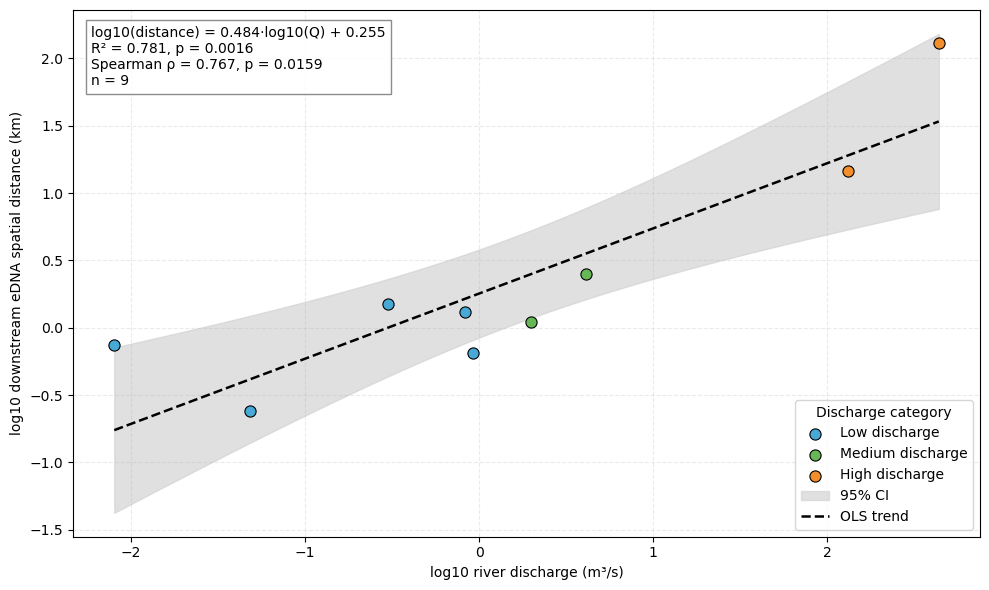

In [10]:
# Values for plotting
x = discharge_data["logQ"].to_numpy()
y = discharge_data["logDistance"].to_numpy()
x_line = np.linspace(x.min(), x.max(), 200)
y_line = regression.intercept + regression.slope * x_line
# Calculate the 95% confidence interval for shading
fitted_values = regression.intercept + regression.slope * x
residuals = y - fitted_values
residual_error = np.sqrt(
    np.sum(residuals ** 2) / (len(x) - 2)
)
x_variation = np.sum((x - x.mean()) ** 2)
confidence_error = (
    stats.t.ppf(0.975, len(x) - 2)
    * residual_error
    * np.sqrt(
        1 / len(x)
        + (x_line - x.mean()) ** 2 / x_variation
    )
)
colours = {
    "Low discharge": "#48A9D6",
    "Medium discharge": "#67B757",
    "High discharge": "#F28E2B"
}
fig, ax = plt.subplots(figsize=(10, 6))
for category, colour in colours.items():
    group = discharge_data[
        discharge_data["Category"] == category
    ]
    ax.scatter(
        group["logQ"],
        group["logDistance"],
        s=65,
        color=colour,
        edgecolor="black",
        linewidth=0.8,
        label=category,
        zorder=3
    )
ax.fill_between(
    x_line,
    y_line - confidence_error,
    y_line + confidence_error,
    color="lightgrey",
    alpha=0.7,
    label="95% CI"
)
# Regression line
ax.plot(
    x_line,
    y_line,
    color="black",
    linestyle="--",
    linewidth=1.8,
    label="OLS trend"
)
# Statistical summary
statistics_text = (
    f"log10(distance) = {regression.slope:.3f}·log10(Q) "
    f"+ {regression.intercept:.3f}\n"
    f"R² = {r_squared:.3f}, p = {regression.pvalue:.4f}\n"
    f"Spearman ρ = {rho:.3f}, p = {spearman_p:.4f}\n"
    f"n = {len(discharge_data)}"
)
ax.text(
    0.02,
    0.97,
    statistics_text,
    transform=ax.transAxes,
    va="top",
    bbox={
        "facecolor": "white",
        "edgecolor": "grey",
        "alpha": 0.9
    }
)
ax.set_xlabel("log10 river discharge (m³/s)")
ax.set_ylabel("log10 downstream eDNA spatial distance (km)")
ax.grid(
    linestyle="--",
    alpha=0.25
)
ax.legend(
    title="Discharge category",
    frameon=True,
    loc="lower right"
)
plt.tight_layout()
plt.savefig(
    "Figure 6: Relationship between river discharge and reported eDNA spatial scale. .png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Figure 7: Field-sampling effort across reviewed riverine fish eDNA studies.
Field-sampling effort was summarised using the number of sampling sites, the number of replicates collected per site and the volume of water filtered. Each point represents one study. Point colour indicates the filtered volume per replicate, and point size indicates the total filtered volume per site.

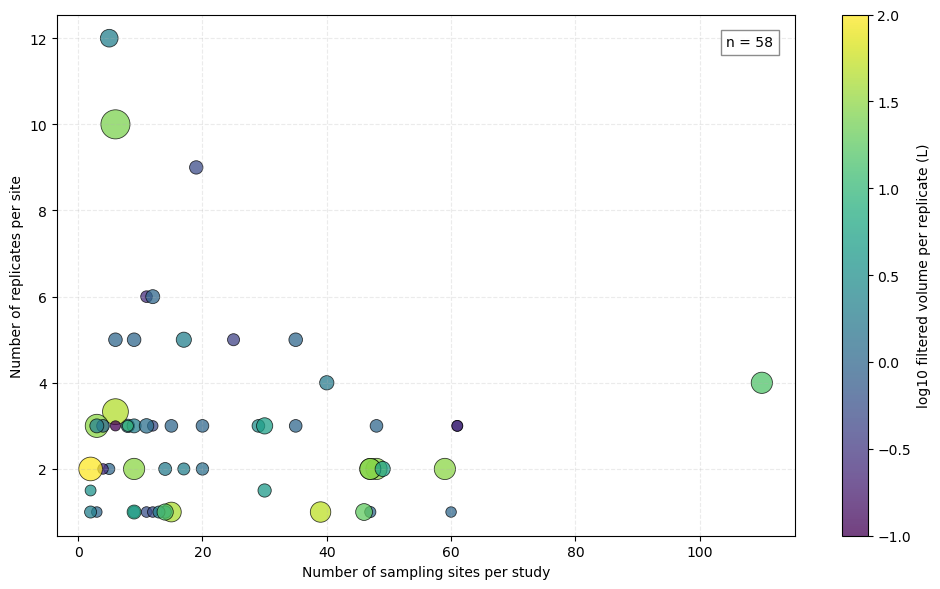

In [11]:
sampling = study_data[
    [
        "Number of sampling sites (avg)",
        "Replicates per site (avg)",
        "Volume per sample (L) (avg)",
        "Total filtered volume per site(L) (avg)"
    ]
].copy()

sampling.columns = [
    "Sites",
    "Replicates",
    "Volume per replicate",
    "Total volume per site"
]

sampling = sampling.apply(pd.to_numeric, errors="coerce")

sampling = sampling.dropna(
    subset=["Sites", "Replicates", "Volume per replicate"]
)

sampling["Total volume per site"] = sampling[
    "Total volume per site"
].fillna(
    sampling["Replicates"] * sampling["Volume per replicate"]
)

# Log-transform volume for the colour scale
sampling["Log volume"] = np.log10(
    sampling["Volume per replicate"]
)

# Scale bubble sizes
bubble_sizes = (
    40 + np.sqrt(sampling["Total volume per site"]) * 25
)

# Figure 7: Field-sampling effort across reviewed riverine fish eDNA studies.
fig, ax = plt.subplots(figsize=(10, 6))

points = ax.scatter(
    sampling["Sites"],
    sampling["Replicates"],
    c=sampling["Log volume"],
    s=bubble_sizes,
    cmap="viridis",
    alpha=0.75,
    edgecolor="black",
    linewidth=0.6
)
colour_bar = fig.colorbar(points, ax=ax)
colour_bar.set_label("log10 filtered volume per replicate (L)")
ax.text(
    0.97,
    0.96,
    f"n = {len(sampling)}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox={
        "facecolor": "white",
        "edgecolor": "grey",
        "alpha": 0.9
    }
)
ax.set_xlabel("Number of sampling sites per study")
ax.set_ylabel("Number of replicates per site")

ax.grid(
    linestyle="--",
    alpha=0.25
)
plt.tight_layout()
plt.savefig(
    "Figure 7: Field-sampling effort across reviewed riverine fish eDNA studies..png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Figure 8: Filtered volume per sample Vs Number of replicates per site

Relationship between filtered volume per replicate and the number of replicates collected per site across all studies and after excluding the two high-replication experimental studies.
In the sensitivity analysis, Bylemans et al. (2018), Cantera et al. (2019) and Lee et al. (2024) were excluded because their sampling designs used comparatively intensive replication for methodological purposes.

**Figure 8:** Relationship between filtered volume per replicate and the number of replicates collected per site: (A) all reviewed studies and (B) sensitivity analysis excluding three method-development studies. The dashed line in each panel shows the fitted linear trend.

All studies
Spearman ρ = -0.255
p = 0.0536
n = 58

Sensitivity analysis excluding method-development studies
Spearman ρ = -0.286
p = 0.0341
n = 55

Excluded studies:
      Author  Year  Replicates  Volume
6   Bylemans  2018        12.0     2.0
7   Cantera   2019        10.0    25.5
30       Lee  2024         9.0     0.5


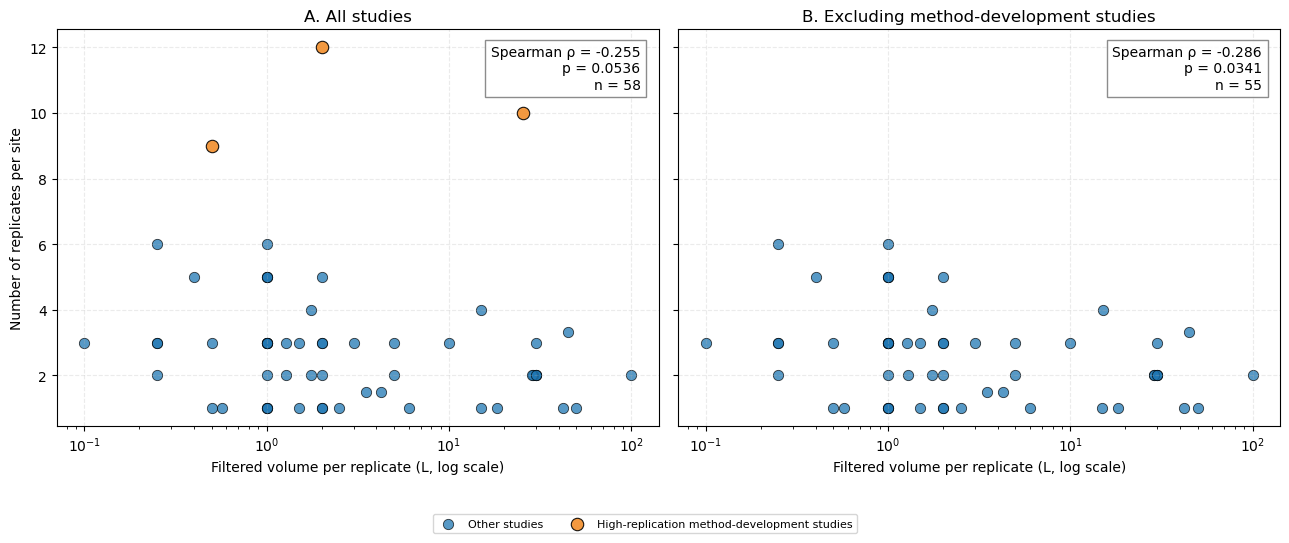

In [12]:
replicate_volume = study_data[
    [
        "First Author",
        "Publish Year",
        "Replicates per site (avg)",
        "Volume per sample (L) (avg)"
    ]
].copy()
replicate_volume.columns = [
    "Author",
    "Year",
    "Replicates",
    "Volume"
]
replicate_volume["Year"] = pd.to_numeric(
    replicate_volume["Year"],
    errors="coerce"
)
replicate_volume["Replicates"] = pd.to_numeric(
    replicate_volume["Replicates"],
    errors="coerce"
)
replicate_volume["Volume"] = pd.to_numeric(
    replicate_volume["Volume"],
    errors="coerce"
)
replicate_volume = replicate_volume.dropna(
    subset=["Author", "Year", "Replicates", "Volume"]
)

replicate_volume = replicate_volume[
    replicate_volume["Volume"] > 0
].copy()

replicate_volume["Author cleaned"] = (
    replicate_volume["Author"]
    .astype(str)
    .str.strip()
    .str.lower()
)
# Identied the three high-replication method-development studies
experimental_mask = (
    (
        replicate_volume["Author cleaned"].str.contains(
            "bylemans",
            na=False
        )
        & replicate_volume["Year"].eq(2018)
    )
    |
    (
        replicate_volume["Author cleaned"].str.contains(
            "cantera",
            na=False
        )
        & replicate_volume["Year"].eq(2019)
    )
    |
    (
        replicate_volume["Author cleaned"].str.contains(
            "lee",
            na=False
        )
        & replicate_volume["Year"].eq(2024)
    )
)

# Create datasets
all_studies = replicate_volume.copy()

experimental_studies = replicate_volume[
    experimental_mask
].copy()

regular_studies = replicate_volume[
    ~experimental_mask
].copy()

reduced_studies = regular_studies.copy()

# Spearman correlations
rho_all, p_all = stats.spearmanr(
    all_studies["Volume"],
    all_studies["Replicates"]
)

rho_reduced, p_reduced = stats.spearmanr(
    reduced_studies["Volume"],
    reduced_studies["Replicates"]
)

# Print results
print("All studies")
print(f"Spearman ρ = {rho_all:.3f}")
print(f"p = {p_all:.4f}")
print(f"n = {len(all_studies)}")

print("\nSensitivity analysis excluding method-development studies")
print(f"Spearman ρ = {rho_reduced:.3f}")
print(f"p = {p_reduced:.4f}")
print(f"n = {len(reduced_studies)}")

print("\nExcluded studies:")
print(
    experimental_studies[
        ["Author", "Year", "Replicates", "Volume"]
    ]
)

# Create side-by-side figure
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.5),
    sharex=True,
    sharey=True
)

# Panel A: all studies
axes[0].scatter(
    regular_studies["Volume"],
    regular_studies["Replicates"],
    s=55,
    color="#1F77B4",
    edgecolor="black",
    linewidth=0.6,
    alpha=0.75,
    label="Other studies"
)
axes[0].scatter(
    experimental_studies["Volume"],
    experimental_studies["Replicates"],
    s=80,
    color="#F28E2B",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    label="High-replication method-development studies",
    zorder=3
)
axes[0].set_xscale("log")

axes[0].set_title(
    "A. All studies"
)
axes[0].set_xlabel(
    "Filtered volume per replicate (L, log scale)"
)
axes[0].set_ylabel(
    "Number of replicates per site"
)
axes[0].text(
    0.97,
    0.96,
    (
        f"Spearman ρ = {rho_all:.3f}\n"
        f"p = {p_all:.4f}\n"
        f"n = {len(all_studies)}"
    ),
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    bbox={
        "facecolor": "white",
        "edgecolor": "grey",
        "alpha": 0.9
    }
)
axes[0].grid(
    linestyle="--",
    alpha=0.25
)

# Panel B: sensitivity analysis

axes[1].scatter(
    reduced_studies["Volume"],
    reduced_studies["Replicates"],
    s=55,
    color="#1F77B4",
    edgecolor="black",
    linewidth=0.6,
    alpha=0.75
)
axes[1].set_xscale("log")

axes[1].set_title(
    "B. Excluding method-development studies"
)
axes[1].set_xlabel(
    "Filtered volume per replicate (L, log scale)"
)
axes[1].text(
    0.97,
    0.96,
    (
        f"Spearman ρ = {rho_reduced:.3f}\n"
        f"p = {p_reduced:.4f}\n"
        f"n = {len(reduced_studies)}"
    ),
    transform=axes[1].transAxes,
    ha="right",
    va="top",
    bbox={
        "facecolor": "white",
        "edgecolor": "grey",
        "alpha": 0.9
    }
)
axes[1].grid(
    linestyle="--",
    alpha=0.25
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    frameon=True,
    fontsize=8
)

plt.tight_layout(
    rect=[0, 0.10, 1, 1]
)

# save the fig
plt.savefig(
    "Figure 8: Replicates vs volume sensitivity analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Figure 9: Filtered water volume per sample according to filter format.

               count   mean  median
Filter format                      
Encapsulated      21  22.72    25.5
Open membrane     37   2.44     1.5

Mann–Whitney U = 559.0
p = 0.0056


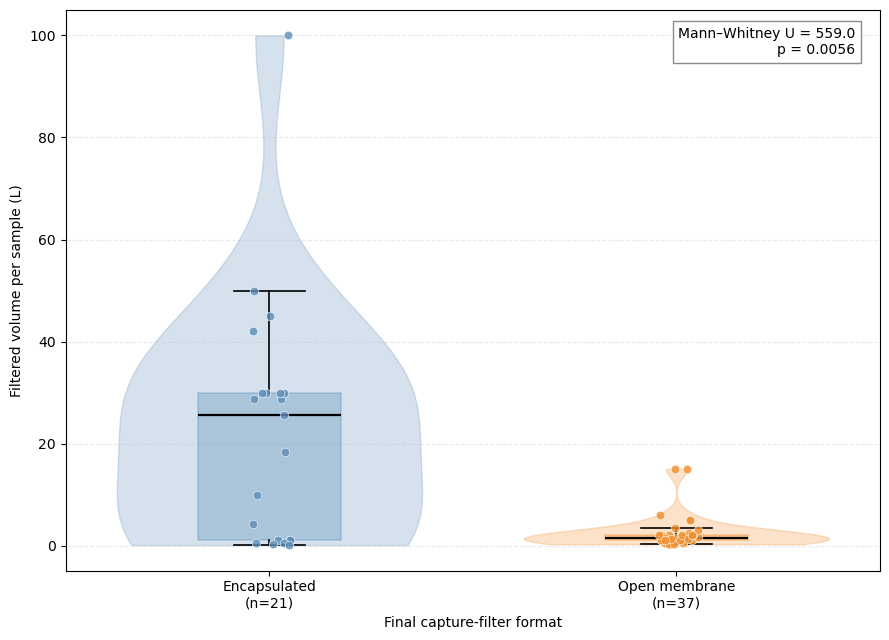

In [13]:
filter_volume = (
    study_data[
        ["Filter format", "Volume per sample (L) (avg)"]
    ]
    .dropna()
    .rename(
        columns={
            "Volume per sample (L) (avg)": "Volume"
        }
    )
)
encapsulated = filter_volume.loc[
    filter_volume["Filter format"] == "Encapsulated",
    "Volume"
]
open_membrane = filter_volume.loc[
    filter_volume["Filter format"] == "Open membrane",
    "Volume"
]
volume_groups = [
    encapsulated,
    open_membrane
]
# Mann–Whitney U test
u_stat, p_value = stats.mannwhitneyu(
    encapsulated,
    open_membrane,
    alternative="two-sided"
)

# Descriptive statistics
summary = (
    filter_volume
    .groupby("Filter format")["Volume"]
    .agg(["count", "mean", "median"])
    .reindex(["Encapsulated", "Open membrane"])
)
print(summary.round(2))
print(f"\nMann–Whitney U = {u_stat:.1f}")
print(f"p = {p_value:.4f}")
# Create Figure 9
fig, ax = plt.subplots(figsize=(9, 6.5))
positions = [1, 2]
colours = ["#5B8DB8", "#F28E2B"]
# Violin plots
violins = ax.violinplot(
    volume_groups,
    positions=positions,
    widths=0.75,
    showmeans=False,
    showmedians=False,
    showextrema=False
)
for body, colour in zip(violins["bodies"], colours):
    body.set_facecolor(colour)
    body.set_edgecolor(colour)
    body.set_alpha(0.25)
# Boxplots
boxplots = ax.boxplot(
    volume_groups,
    positions=positions,
    widths=0.35,
    patch_artist=True,
    showfliers=False,
    medianprops={
        "color": "black",
        "linewidth": 1.6
    },
    boxprops={"linewidth": 1.2},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2}
)
for box, colour in zip(boxplots["boxes"], colours):
    box.set_facecolor(colour)
    box.set_edgecolor(colour)
    box.set_alpha(0.35)

rng = np.random.default_rng(10)

for position, group, colour in zip(
    positions,
    volume_groups,
    colours
):
    ax.scatter(
        rng.uniform(
            position - 0.055,
            position + 0.055,
            len(group)
        ),
        group,
        s=38,
        color=colour,
        edgecolor="white",
        linewidth=0.5,
        alpha=0.8,
        zorder=3
    )
ax.text(
    0.97,
    0.97,
    (
        f"Mann–Whitney U = {u_stat:.1f}\n"
        f"p = {p_value:.4f}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox={
        "facecolor": "white",
        "edgecolor": "grey",
        "alpha": 0.9
    }
)

ax.set_xticks(positions)
ax.set_xticklabels(
    [
        f"Encapsulated\n(n={len(encapsulated)})",
        f"Open membrane\n(n={len(open_membrane)})"
    ]
)
ax.set_xlabel("Final capture-filter format")
ax.set_ylabel("Filtered volume per sample (L)")
ax.grid(axis="y", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.savefig(
    "Figure 9: Filtered water volume per sample by filter format..png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Figure 10: Filter pore size across interpreted turbidity categories

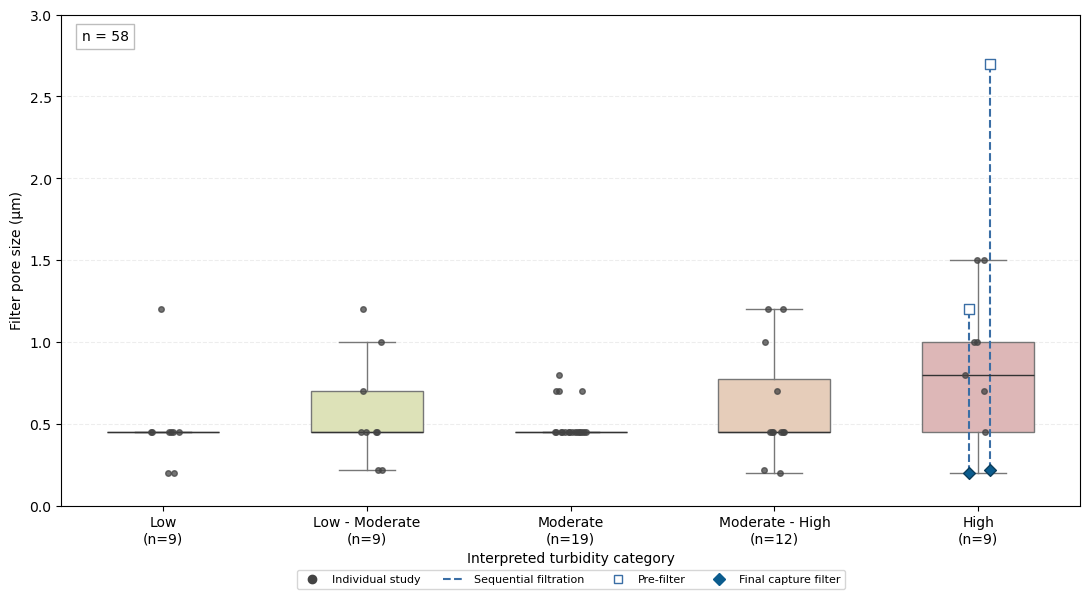

In [14]:
from matplotlib.lines import Line2D

# Prepare data
pore_data = study_data[
    [
        "Interpreted turbidity category",
        "Min Pore (µm)",
        "Max Pore (µm)",
        "Pre-filter / Sequential"
    ]
].copy()

pore_data.columns = ["Turbidity", "Min pore", "Max pore", "Sequential"]

pore_data[["Min pore", "Max pore"]] = pore_data[
    ["Min pore", "Max pore"]
].apply(pd.to_numeric, errors="coerce")

order = [
    "Low",
    "Low - Moderate",
    "Moderate",
    "Moderate - High",
    "High"
]

pore_data = pore_data[
    pore_data["Turbidity"].isin(order)
].copy()

pore_data["Sequential"] = pore_data["Sequential"].eq("Yes")
pore_data["Final pore"] = pore_data[["Min pore", "Max pore"]].min(axis=1)
pore_data["Pre-filter pore"] = pore_data[["Min pore", "Max pore"]].max(axis=1)

pore_data.loc[
    ~pore_data["Sequential"],
    "Pre-filter pore"
] = np.nan

pore_data = pore_data.dropna(subset=["Final pore"])

pore_data["Turbidity"] = pd.Categorical(
    pore_data["Turbidity"],
    categories=order,
    ordered=True
)

pore_data["x"] = pore_data["Turbidity"].cat.codes + 1

counts = pore_data["Turbidity"].value_counts().reindex(order, fill_value=0)

box_data = [
    pore_data.loc[pore_data["Turbidity"] == category, "Final pore"]
    for category in order
]

# Create figure
fig, ax = plt.subplots(figsize=(11, 6.5))

positions = range(1, 6)
colours = ["#BFD8C6", "#DDE2B8", "#D9D9D9", "#E6CDBA", "#DDB7B7"]

box = ax.boxplot(
    box_data,
    positions=positions,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "#333333"},
    boxprops={"edgecolor": "#777777"},
    whiskerprops={"color": "#777777"},
    capprops={"color": "#777777"}
)

for patch, colour in zip(box["boxes"], colours):
    patch.set_facecolor(colour)

# Add study observations
rng = np.random.default_rng(42)
pore_data["jitter"] = pore_data["x"] + rng.uniform(
    -0.08,
    0.08,
    len(pore_data)
)

single = pore_data[~pore_data["Sequential"]]
sequential = pore_data[pore_data["Sequential"]]

ax.scatter(
    single["jitter"],
    single["Final pore"],
    s=16,
    color="#444444",
    alpha=0.75,
    zorder=4
)

for _, row in sequential.iterrows():
    ax.plot(
        [row["jitter"], row["jitter"]],
        [row["Final pore"], row["Pre-filter pore"]],
        "--",
        color="#3A6EA5",
        linewidth=1.5
    )

ax.scatter(
    sequential["jitter"],
    sequential["Pre-filter pore"],
    marker="s",
    s=42,
    facecolor="white",
    edgecolor="#3A6EA5",
    zorder=4
)

ax.scatter(
    sequential["jitter"],
    sequential["Final pore"],
    marker="D",
    s=36,
    color="#0B5C8E",
    edgecolor="#0B3D5C",
    zorder=5
)

# Formatting
ax.text(
    0.02,
    0.97,
    f"n = {len(pore_data)}",
    transform=ax.transAxes,
    va="top",
    bbox={"facecolor": "white", "edgecolor": "#BDBDBD"}
)

ax.set_xticks(positions)
ax.set_xticklabels(
    [f"{category}\n(n={counts[category]})" for category in order]
)

ax.set_xlabel("Interpreted turbidity category")
ax.set_ylabel("Filter pore size (µm)")
ax.set_ylim(0, 3)
ax.grid(axis="y", linestyle="--", alpha=0.22)

legend = [
    Line2D([], [], marker="o", linestyle="", color="#444444",
           label="Individual study"),
    Line2D([], [], linestyle="--", color="#3A6EA5",
           label="Sequential filtration"),
    Line2D([], [], marker="s", linestyle="", markerfacecolor="white",
           markeredgecolor="#3A6EA5", label="Pre-filter"),
    Line2D([], [], marker="D", linestyle="", color="#0B5C8E",
           label="Final capture filter")
]

ax.legend(
    handles=legend,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    fontsize=8
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

plt.savefig(
    "Figure 10: Filter pore size across interpreted turbidity categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Figure 11: Distribution of DNA extraction categories across the reviewed studies. 
DNA extraction methods were grouped into five broader categories to reduce fragmentation caused by individual kit names and combined extraction workflows. The categories were DNeasy Blood & Tissue-based, PowerWater-based, combined tissue–soil workflows, PowerSoil-based and other extraction methods.
Bar labels show the number of studies assigned to each category.

,Number of studies,Percentage (%)
Extraction category,,
DNeasy Blood & Tissue-based,23.0,39.7
PowerWater-based,15.0,25.9
Combined tissue–soil workflow,10.0,17.2
PowerSoil-based,3.0,5.2
Other extraction methods,7.0,12.1
Total,58.0,100.0


Extraction category,Combined tissue–soil workflow,DNeasy Blood & Tissue-based,Other extraction methods,PowerSoil-based,PowerWater-based
Extraction kit,,,,,
MoBio PowerWater,0,0,0,0,3
Nexxtec 1-step,0,0,1,0,0
OMEGA / E.Z.N.A.,0,0,3,0,0
Organic / solvent-based extraction,0,0,3,0,0
Qiagen DNeasy Blood & Tissue,0,23,0,0,0
Qiagen DNeasy Blood & Tissue + NucleoSpin Soil,9,0,0,0,0
Qiagen DNeasy Blood & Tissue + Qiagen PowerSoil,1,0,0,0,0
Qiagen PowerLyzer PowerSoil,0,0,0,2,0
Qiagen PowerSoil Pro,0,0,0,1,0


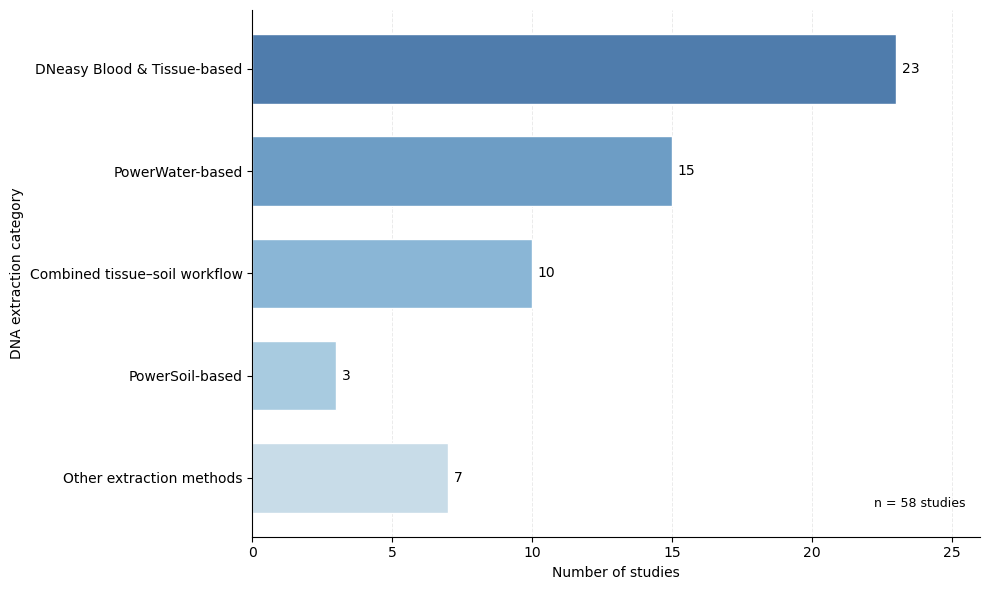

In [15]:
extraction_data = study_data[
    ["DNA extraction kit (Std)"]
].copy()

extraction_data.columns = ["Extraction kit"]
extraction_data = extraction_data.dropna()

# Group individual methods into broader categories
def group_extraction_method(method):

    text = str(method).strip().lower()

    # Combined workflows 
    if (
        "nucleospin soil" in text
        or (
            "dneasy blood & tissue" in text
            and "powersoil" in text
        )
    ):
        return "Combined tissue–soil workflow"

    if "powerwater" in text:
        return "PowerWater-based"

    if "powersoil" in text:
        return "PowerSoil-based"

    if "dneasy blood & tissue" in text:
        return "DNeasy Blood & Tissue-based"

    return "Other extraction methods"


extraction_data["Extraction category"] = (
    extraction_data["Extraction kit"]
    .apply(group_extraction_method)
)


# order of categories
category_order = [
    "DNeasy Blood & Tissue-based",
    "PowerWater-based",
    "Combined tissue–soil workflow",
    "PowerSoil-based",
    "Other extraction methods"
]


# Count  studies
extraction_counts = (
    extraction_data["Extraction category"]
    .value_counts()
    .reindex(category_order, fill_value=0)
)

total_studies = extraction_counts.sum()


# Create a summary table
extraction_summary = pd.DataFrame(
    {
        "Number of studies": extraction_counts,
        "Percentage (%)": (
            extraction_counts / total_studies * 100
        ).round(1)
    }
)
extraction_summary.loc["Total"] = [
    total_studies,
    100.0
]
display(extraction_summary)

# Show which original extraction methods entered each category
extraction_check = pd.crosstab(
    extraction_data["Extraction kit"],
    extraction_data["Extraction category"]
)
display(extraction_check)

# Create the horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colours = [
    "#4F7CAC",
    "#6D9DC5",
    "#8AB6D6",
    "#A8CBE0",
    "#C8DCE8"
]
bars = ax.barh(
    category_order,
    extraction_counts,
    color=colours,
    edgecolor="white",
    height=0.68
)
ax.invert_yaxis()

for bar, count in zip(bars, extraction_counts):

    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center",
        fontsize=10
    )
# Figure formatting
ax.set_xlabel("Number of studies")
ax.set_ylabel("DNA extraction category")

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(
    0,
    extraction_counts.max() + 3
)
ax.text(
    0.98,
    0.05,
    f"n = {total_studies} studies",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9
)
plt.tight_layout()
plt.savefig(
    "Figure 11: Distribution of DNA extraction methods across reviewed riverine fish eDNA studies..png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Figure 12a: Distribution of target genes used across the reviewed studies. 
The legend shows the number and percentage of studies assigned to each target-gene category.

,Number of studies,Percentage (%)
12S rRNA,33.0,56.9
Multi-gene,9.0,15.5
COI,6.0,10.3
Cytb,6.0,10.3
16S rRNA,1.0,1.7
Other marker,3.0,5.2
Total,58.0,100.0


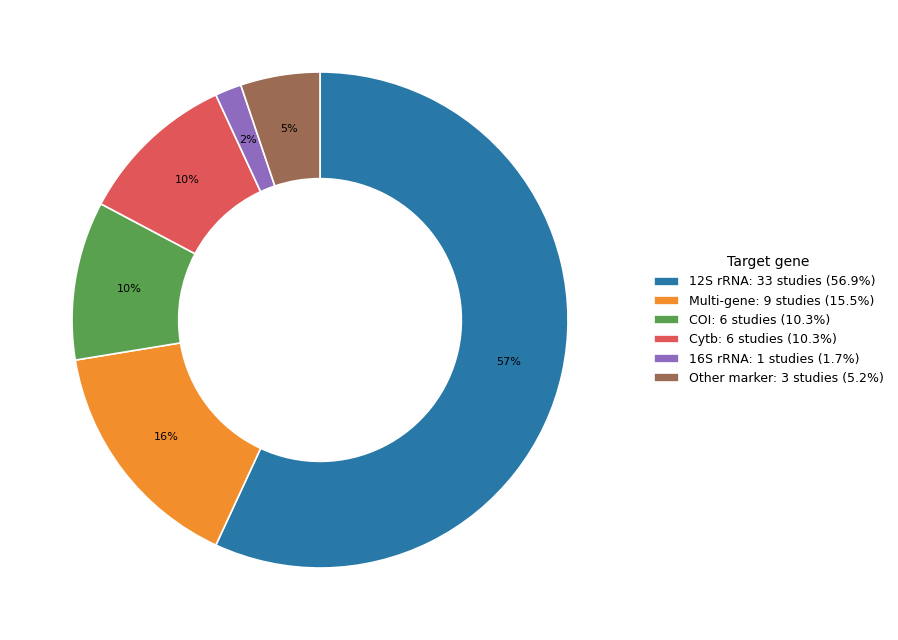

In [16]:
# Figure 12a: Target genes

gene = study_data["Target marker gene (Std)"].dropna().str.lower().str.strip()

categories = np.select(
    [
        gene.str.contains(r"\+|multi"),
        gene.str.contains("12s"),
        gene.eq("coi") | gene.str.contains("cox1"),
        gene.str.contains("cytb") | gene.str.contains("cytochrome b"),
        gene.str.contains("16s")
    ],
    [
        "Multi-gene",
        "12S rRNA",
        "COI",
        "Cytb",
        "16S rRNA"
    ],
    default="Other marker"
)

order = [
    "12S rRNA",
    "Multi-gene",
    "COI",
    "Cytb",
    "16S rRNA",
    "Other marker"
]

counts = pd.Series(categories).value_counts().reindex(order, fill_value=0)
percentages = counts / counts.sum() * 100

summary = pd.DataFrame({
    "Number of studies": counts,
    "Percentage (%)": percentages.round(1)
})

summary.loc["Total"] = [counts.sum(), 100.0]
display(summary)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6.5))

colours = [
    "#2878A8",
    "#F28E2B",
    "#59A14F",
    "#E15759",
    "#8E6BBE",
    "#9C6B53"
]

wedges, _, _ = ax.pie(
    counts,
    startangle=90,
    counterclock=False,
    colors=colours,
    autopct=lambda p: f"{p:.0f}%",
    pctdistance=0.78,
    wedgeprops={
        "width": 0.43,
        "edgecolor": "white",
        "linewidth": 1.2
    },
    textprops={"fontsize": 8}
)

labels = [
    f"{g}: {c} studies ({p:.1f}%)"
    for g, c, p in zip(order, counts, percentages)
]

ax.legend(
    wedges,
    labels,
    title="Target gene",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

ax.set_aspect("equal")
plt.tight_layout()

plt.savefig(
    "Figure 12a: Distribution of standardised target-gene categories across reviewed studies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Figure 12b:Distribution of the most frequently used primer systems or assays across the reviewed studies. 
To improve readability in a compact figure format, the most frequently used primer systems or assays were shown individually, while all remaining low-frequency categories were grouped as “Other primer systems / combinations”.

,Primer system,Number of studies
0,Species-specific assay,16
1,MiFish,14
2,Teleo / Tele02,14
3,12S-V5,3
4,Other primer systems / combinations,11


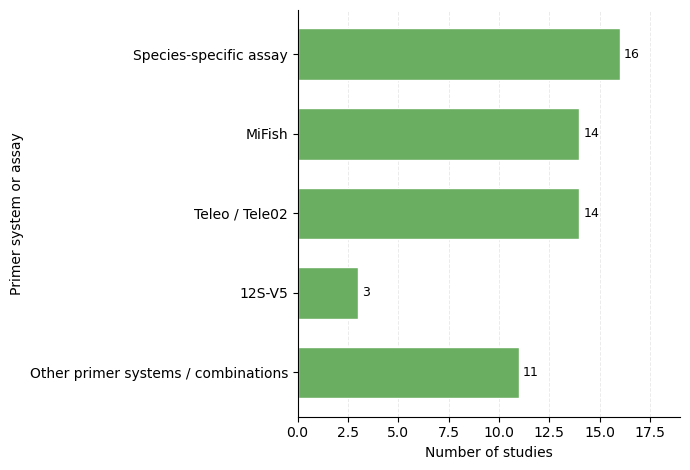

In [17]:
primer_data = study_data[
    ["Primer system / assay (Std)"]
].copy()

primer_data.columns = ["Primer system"]
primer_data = primer_data.dropna()

primer_data["Primer system"] = (
    primer_data["Primer system"]
    .astype(str)
    .str.strip()
)

primer_counts = primer_data["Primer system"].value_counts()
top_n = 4
top_counts = primer_counts.iloc[:top_n].copy()
other_count = primer_counts.iloc[top_n:].sum()
# Add the grouped "Other" category
summary_counts = top_counts.copy()
if other_count > 0:
    summary_counts["Other primer systems / combinations"] = other_count
# Convert to dataframe
primer_summary = summary_counts.reset_index()
primer_summary.columns = ["Primer system", "Number of studies"]

display(primer_summary)
# Plot
fig, ax = plt.subplots(figsize=(7, 4.8))
bars = ax.barh(
    primer_summary["Primer system"],
    primer_summary["Number of studies"],
    color="#6AAE61",
    edgecolor="white",
    height=0.65
)

# Highest value at top
ax.invert_yaxis()

# Add count labels
for bar, value in zip(bars, primer_summary["Number of studies"]):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
        fontsize=9
    )
# Formatting
ax.set_xlabel("Number of studies")
ax.set_ylabel("Primer system or assay")

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, primer_summary["Number of studies"].max() + 3)
plt.tight_layout()
plt.savefig(
    "Figure 12b: Distribution of standardised primer-system and assay categories across the reviewed riverine fish eDNA studies..png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Figure 13: Association between target-gene categories and primer systems across the 58 reviewed studies. 

Cell values indicate the number of studies using each combination. Darker shading represents combinations reported by a larger number of studies.

Total studies represented: 58


Primer category,12S-V5,COI metabarcoding,Cytb metabarcoding,Fish-F4/R4,MiFish,MiFish + 16S,MiFish + COI,Multi-marker,Species-specific,Teleo/Tele02,Teleostei primer
Target-gene category,,,,,,,,,,,
12S rRNA,3,0,0,1,13,0,0,0,1,14,1
16S rRNA,0,0,0,0,0,0,0,0,1,0,0
COI,0,2,0,0,0,0,0,0,4,0,0
Cytb,0,0,1,0,0,0,0,0,5,0,0
Multi-gene,0,0,0,0,1,1,1,2,3,1,0
Other marker,0,0,0,0,0,0,0,0,3,0,0


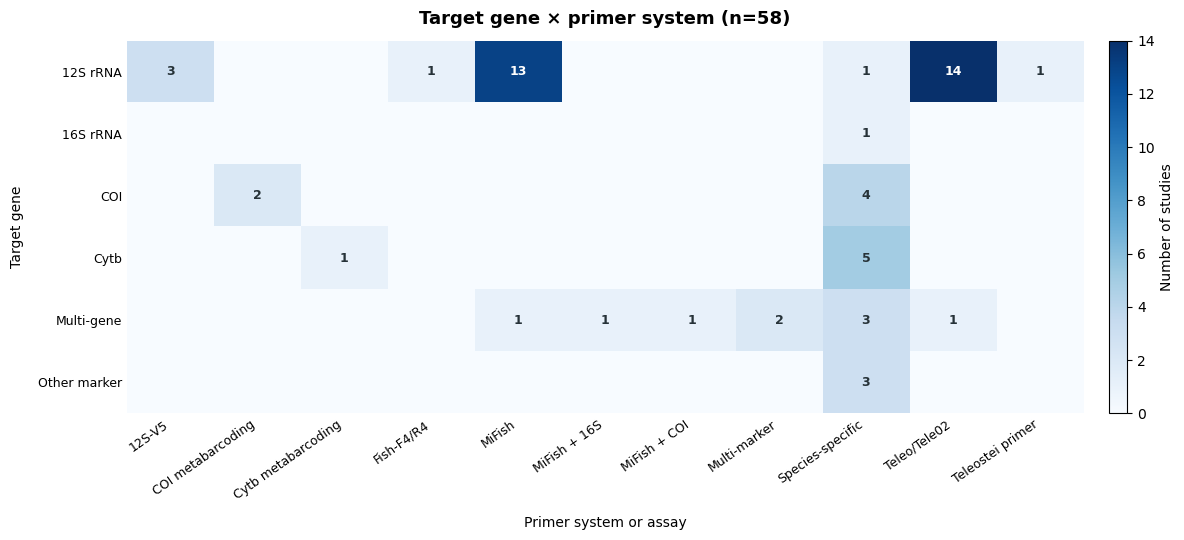

In [18]:
# Figure 13: Target gene × primer system
matrix_data = study_data[
    [
        "Target marker gene (Std)",
        "Primer system / assay (Std)"
    ]
].copy()
matrix_data.columns = [
    "Target gene",
    "Primer system"
]
matrix_data = matrix_data.dropna()

def group_gene(value):

    gene = str(value).strip()

    if gene in ["12S rRNA", "16S rRNA", "COI", "Cytb"]:
        return gene

    if "+" in gene:
        return "Multi-gene"

    return "Other marker"
def group_primer(value):

    primer = str(value).strip()

    if primer in [
        "Species-specific assay",
        "Species-specific assay + Teleo / Tele02"
    ]:
        return "Species-specific"

    if primer in [
        "Teleo / Tele02",
        "Teleo / Tele02 + COI metabarcoding"
    ]:
        return "Teleo/Tele02"
    replacements = {
        "Multi-marker assay": "Multi-marker",
        "MiFish + 16S metabarcoding": "MiFish + 16S",
        "MiFish + COI metabarcoding": "MiFish + COI"
    }
    return replacements.get(primer, primer)
matrix_data["Target-gene category"] = (
    matrix_data["Target gene"].apply(group_gene)
)
matrix_data["Primer category"] = (
    matrix_data["Primer system"].apply(group_primer)
)

# Set the row and column order
gene_order = [
    "12S rRNA",
    "16S rRNA",
    "COI",
    "Cytb",
    "Multi-gene",
    "Other marker"
]
primer_order = [
    "12S-V5",
    "COI metabarcoding",
    "Cytb metabarcoding",
    "Fish-F4/R4",
    "MiFish",
    "MiFish + 16S",
    "MiFish + COI",
    "Multi-marker",
    "Species-specific",
    "Teleo/Tele02",
    "Teleostei primer"
]
# Create the matrix
gene_primer_matrix = pd.crosstab(
    matrix_data["Target-gene category"],
    matrix_data["Primer category"]
)
gene_primer_matrix = gene_primer_matrix.reindex(
    index=gene_order,
    columns=primer_order,
    fill_value=0
)
gene_primer_matrix = gene_primer_matrix.loc[
    :,
    gene_primer_matrix.sum(axis=0) > 0
]
print(
    "Total studies represented:",
    gene_primer_matrix.to_numpy().sum()
)
display(gene_primer_matrix)
# Create the heatmap
fig, ax = plt.subplots(
    figsize=(12, 5.5)
)
heatmap = ax.imshow(
    gene_primer_matrix,
    cmap="Blues",
    aspect="auto",
    vmin=0
)
# Axis labels
ax.set_xticks(
    range(len(gene_primer_matrix.columns))
)

ax.set_xticklabels(
    gene_primer_matrix.columns,
    rotation=35,
    ha="right",
    fontsize=9
)

ax.set_yticks(
    range(len(gene_primer_matrix.index))
)
ax.set_yticklabels(
    gene_primer_matrix.index,
    fontsize=9
)
ax.set_xlabel(
    "Primer system or assay",
    labelpad=10
)
ax.set_ylabel(
    "Target gene",
    labelpad=10
)
ax.set_title(
    f"Target gene × primer system (n={len(matrix_data)})",
    fontsize=13,
    fontweight="bold",
    pad=12
)
highest_value = gene_primer_matrix.to_numpy().max()

for row in range(len(gene_primer_matrix.index)):

    for column in range(len(gene_primer_matrix.columns)):

        value = gene_primer_matrix.iloc[row, column]

        if value > 0:

            text_colour = (
                "white"
                if value > highest_value * 0.55
                else "#263238"
            )

            ax.text(
                column,
                row,
                str(int(value)),
                ha="center",
                va="center",
                color=text_colour,
                fontsize=9,
                fontweight="bold"
            )
colour_bar = fig.colorbar(
    heatmap,
    ax=ax,
    fraction=0.035,
    pad=0.025
)
colour_bar.set_label(
    "Number of studies"
)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    length=0
)
plt.tight_layout()
plt.savefig(
    "Figure 13: Association between target-gene categories and primer systems across the 58 reviewed studies. .png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Figure 14: Reference-database use by molecular detection approach among studies with reported database information 

Database,NCBI / GenBank / EMBL,Custom / regional DB,NCBI + custom,Other / mixed
Approach,,,,
Both,2,0,0,0
Metabarcoding,19,12,7,1
Species-specific,7,0,0,0


Studies with reported database information: 48


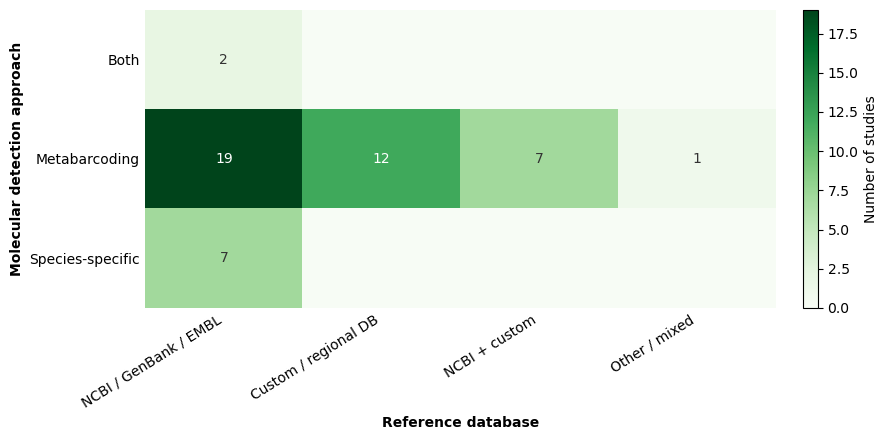

In [19]:
# Molecular approach × reference database
database_data = study_data[
    [
        "Molecular detection approach (Std)",
        "Reference database (Std)"
    ]
].copy()

database_data.columns = ["Approach", "Database"]

# Simplify the molecular-approach names
def group_approach(value):

    text = str(value).lower().replace("-", " ")

    if "both" in text:
        return "Both"

    if "metabarcoding" in text:
        return "Metabarcoding"

    if "species" in text and "specific" in text:
        return "Species-specific"

    return None

# Simplify the database names
def group_database(value):

    if pd.isna(value):
        return None

    text = str(value).strip().lower()

    if text in ["not reported", "-", "–", "not applicable"]:
        return None

    public = any(
        word in text
        for word in ["ncbi", "genbank", "embl"]
    )

    custom = any(
        word in text
        for word in ["custom", "regional", "local"]
    )

    if public and custom:
        return "NCBI + custom"

    if public:
        return "NCBI / GenBank / EMBL"

    if custom:
        return "Custom / regional DB"

    return "Other / mixed"


database_data["Approach"] = database_data["Approach"].apply(
    group_approach
)
database_data["Database"] = database_data["Database"].apply(
    group_database
)
# Keep studies with reported database information
database_data = database_data.dropna(
    subset=["Approach", "Database"]
)
# Create the matrix
approach_order = [
    "Both",
    "Metabarcoding",
    "Species-specific"
]
database_order = [
    "NCBI / GenBank / EMBL",
    "Custom / regional DB",
    "NCBI + custom",
    "Other / mixed"
]
database_matrix = pd.crosstab(
    database_data["Approach"],
    database_data["Database"]
).reindex(
    index=approach_order,
    columns=database_order,
    fill_value=0
)
display(database_matrix)

print(
    "Studies with reported database information:",
    database_matrix.to_numpy().sum()
)
# Plot the heatmap
fig, ax = plt.subplots(figsize=(9, 4.5))
heatmap = ax.imshow(
    database_matrix,
    cmap="Greens",
    aspect="auto",
    vmin=0
)
ax.set_xticks(range(len(database_order)))
ax.set_xticklabels(
    database_order,
    rotation=32,
    ha="right"
)

ax.set_yticks(range(len(approach_order)))
ax.set_yticklabels(approach_order)

ax.set_xlabel(
    "Reference database",
    fontweight="bold"
)
ax.set_ylabel(
    "Molecular detection approach",
    fontweight="bold"
)
highest_value = database_matrix.to_numpy().max()
for row in range(database_matrix.shape[0]):

    for column in range(database_matrix.shape[1]):

        value = database_matrix.iloc[row, column]

        if value > 0:

            ax.text(
                column,
                row,
                str(value),
                ha="center",
                va="center",
                color=(
                    "white"
                    if value > highest_value * 0.55
                    else "#333333"
                )
            )

colour_bar = fig.colorbar(
    heatmap,
    ax=ax,
    fraction=0.04,
    pad=0.04
)
colour_bar.set_label("Number of studies")
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig(
    "Figure 14: Reference-database use by molecular detection approach among studies with reported database information.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Figure 15a: Temporal changes in sequence-clustering methods used in riverine fish eDNA studies. 

Metabarcoding or Both studies: 43
Studies with a reported method: 41
Method not reported: 2

Method totals:
Broad group
Similarity-clustered units    27
Exact sequence variants       14
Name: count, dtype: int64

Original method totals:
Method
OTU      18
ASV      10
MOTU      9
zOTUs     4
Name: count, dtype: int64


Broad group,Similarity-clustered units,Exact sequence variants
Year,,
2016,3,0
2017,0,0
2018,3,0
2019,3,1
2020,4,1
2021,1,4
2022,2,0
2023,3,2
2024,4,1


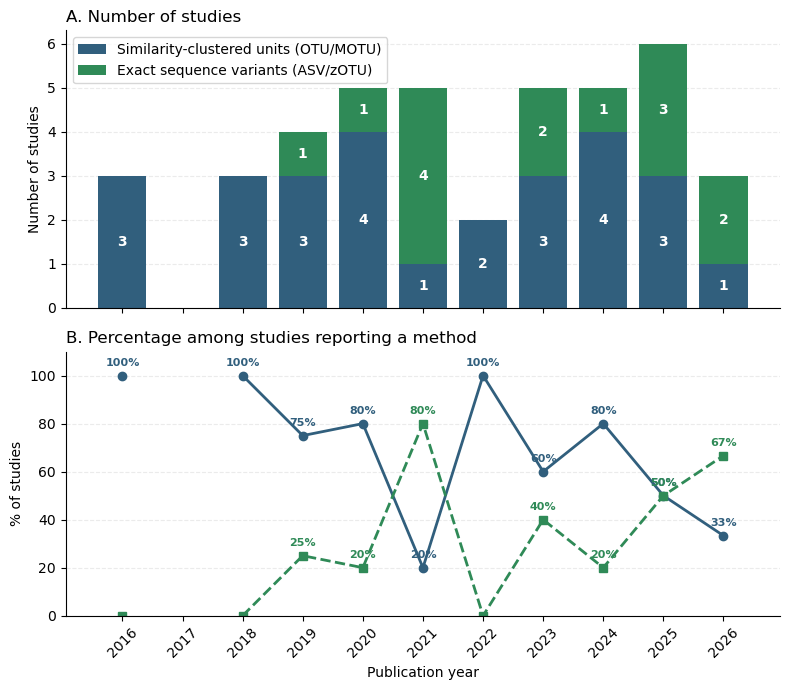

In [20]:
# Clustering strategy over time
cluster_data = study_data[
    [
        "Publish Year",
        "Molecular detection approach (Std)",
        "ASV/OTU method (Std)"
    ]
].copy()

cluster_data.columns = [
    "Year",
    "Approach",
    "Method"
]
cluster_data["Year"] = pd.to_numeric(
    cluster_data["Year"],
    errors="coerce"
)

cluster_data["Approach"] = (
    cluster_data["Approach"]
    .astype(str)
    .str.strip()
)

cluster_data["Method"] = (
    cluster_data["Method"]
    .astype(str)
    .str.strip()
)

# Include metabarcoding studies and studies using both approaches
cluster_data = cluster_data[
    cluster_data["Approach"].isin(
        ["Metabarcoding", "Both"]
    )
].copy()

# Group the methods using the exact wording in the workbook
method_groups = {
    "OTU": "Similarity-clustered units",
    "MOTU": "Similarity-clustered units",
    "ASV": "Exact sequence variants",
    "zOTU/ZOTU": "Exact sequence variants",
    "zOTUs": "Exact sequence variants"
}

cluster_data["Broad group"] = (
    cluster_data["Method"].map(method_groups)
)

not_reported = cluster_data["Broad group"].isna().sum()

plot_data = cluster_data.dropna(
    subset=["Year", "Broad group"]
).copy()

plot_data["Year"] = plot_data["Year"].astype(int)

group_order = [
    "Similarity-clustered units",
    "Exact sequence variants"
]

print("Metabarcoding or Both studies:", len(cluster_data))
print("Studies with a reported method:", len(plot_data))
print("Method not reported:", not_reported)

print("\nMethod totals:")
print(plot_data["Broad group"].value_counts())

print("\nOriginal method totals:")
print(plot_data["Method"].value_counts())

# Count studies
years = range(
    plot_data["Year"].min(),
    plot_data["Year"].max() + 1
)

year_counts = pd.crosstab(
    plot_data["Year"],
    plot_data["Broad group"]
).reindex(
    index=years,
    columns=group_order,
    fill_value=0
)

year_totals = year_counts.sum(axis=1)

year_percentages = year_counts.div(
    year_totals.replace(0, np.nan),
    axis=0
) * 100

display(year_counts)


#figure
fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [1.05, 1]}
)

cluster_colour = "#315F7D"
variant_colour = "#2F8A57"


# Panel A: number of studies
axes[0].bar(
    year_counts.index,
    year_counts["Similarity-clustered units"],
    color=cluster_colour,
    label="Similarity-clustered units (OTU/MOTU)"
)

axes[0].bar(
    year_counts.index,
    year_counts["Exact sequence variants"],
    bottom=year_counts["Similarity-clustered units"],
    color=variant_colour,
    label="Exact sequence variants (ASV/zOTU)"
)
for year in year_counts.index:

    clustered = year_counts.loc[
        year,
        "Similarity-clustered units"
    ]

    variants = year_counts.loc[
        year,
        "Exact sequence variants"
    ]

    if clustered > 0:
        axes[0].text(
            year,
            clustered / 2,
            str(clustered),
            ha="center",
            va="center",
            color="white",
            fontweight="bold"
        )
    if variants > 0:
        axes[0].text(
            year,
            clustered + variants / 2,
            str(variants),
            ha="center",
            va="center",
            color="white",
            fontweight="bold"
        )
axes[0].set_ylabel("Number of studies")
axes[0].set_title("A. Number of studies", loc="left")
axes[0].legend(loc="upper left", frameon=True)
axes[0].grid(axis="y", linestyle="--", alpha=0.25)

# Panel B: percentage of studies reporting each method
axes[1].plot(
    year_percentages.index,
    year_percentages["Similarity-clustered units"],
    marker="o",
    linewidth=2,
    color=cluster_colour,
    label="Similarity-clustered units"
)
axes[1].plot(
    year_percentages.index,
    year_percentages["Exact sequence variants"],
    marker="s",
    linestyle="--",
    linewidth=2,
    color=variant_colour,
    label="Exact sequence variants"
)

for year in year_percentages.index:

    clustered = year_percentages.loc[
        year,
        "Similarity-clustered units"
    ]

    variants = year_percentages.loc[
        year,
        "Exact sequence variants"
    ]
    if pd.notna(clustered) and clustered > 0:
        axes[1].text(
            year,
            clustered + 4,
            f"{clustered:.0f}%",
            ha="center",
            fontsize=8,
            color=cluster_colour,
            fontweight="bold"
        )
    if pd.notna(variants) and variants > 0:
        axes[1].text(
            year,
            variants + 4,
            f"{variants:.0f}%",
            ha="center",
            fontsize=8,
            color=variant_colour,
            fontweight="bold"
        )
axes[1].set_xlabel("Publication year")
axes[1].set_ylabel("% of studies")
axes[1].set_title(
    "B. Percentage among studies reporting a method",
    loc="left"
)
axes[1].set_ylim(0, 110)
axes[1].grid(axis="y", linestyle="--", alpha=0.25)
# Final formatting
for ax in axes:
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
axes[1].set_xticks(list(years))
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(
    "Figure 15a: Temporal changes in sequence-clustering methods used in riverine fish eDNA studies. .png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Figure 15b: Distribution of reported sequence-clustering methods 
Percentages were calculated among studies that reported an OTU-, MOTU-, ASV- or zOTU-based method.

,Number of studies,Percentage (%)
ASV/OTU method (Std),,
OTU,18,43.9
ASV,10,24.4
MOTU,9,22.0
zOTU,4,9.8


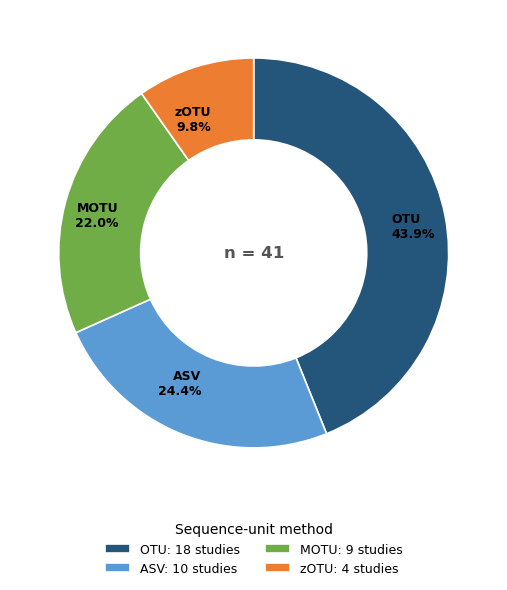

In [21]:
# Donut chart of reported sequence-unit methods
method_data = (
    study_data["ASV/OTU method (Std)"]
    .astype("string")
    .str.strip()
    .replace({
        "zOTU/ZOTU": "zOTU",
        "zOTUs": "zOTU",
        "_": pd.NA
    })
    .dropna()
)

method_order = ["OTU", "ASV", "MOTU", "zOTU"]

method_counts = (
    method_data.value_counts()
    .reindex(method_order, fill_value=0)
)

total = method_counts.sum()
percentages = method_counts / total * 100

display(
    pd.DataFrame({
        "Number of studies": method_counts,
        "Percentage (%)": percentages.round(1)
    })
)

# Create chart
fig, ax = plt.subplots(figsize=(7, 6))

colours = [
    "#24557A",
    "#5B9BD5",
    "#70AD47",
    "#ED7D31"
]
labels = [
    f"{method}\n{percentage:.1f}%"
    for method, percentage in zip(
        method_order,
        percentages
    )
]
wedges, texts = ax.pie(
    method_counts,
    labels=labels,
    startangle=90,
    counterclock=False,
    colors=colours,
    labeldistance=0.72,
    wedgeprops={
        "width": 0.42,
        "edgecolor": "white",
        "linewidth": 1.2
    },
    textprops={
        "fontsize": 9,
        "fontweight": "bold"
    }
)

ax.text(
    0,
    0,
    f"n = {total}",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="#555555"
)
# Legend with study counts

legend_labels = [
    f"{method}: {count} studies"
    for method, count in zip(
        method_order,
        method_counts
    )
]

ax.legend(
    wedges,
    legend_labels,
    title="Sequence-unit method",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=2,
    frameon=False,
    fontsize=9
)
ax.set_aspect("equal")

plt.tight_layout()

plt.savefig(
    "Figure 15b: Distribution of reported sequence-clustering methods.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [22]:
# Create Matrix: collection method × filtration location × filter format
df = study_data[
    ["Filter format", "Water-collection method", "Filtration location"]
].copy()

f = df["Filter format"].fillna("").str.lower()
c = df["Water-collection method"].fillna("").str.lower()
l = df["Filtration location"].fillna("").str.lower()

# Final capture-filter format
df["Filter"] = np.select(
    [
        f.str.contains("encapsulated underneath"),
        f.eq("encapsulated"),
        f.eq("open membrane")
    ],
    ["Encapsulated", "Encapsulated", "Open membrane"],
    default=None
)

# Water-collection method
df["Collection"] = np.select(
    [
        c.str.contains(r"sampling bag|sample bag|sterile bag|plastic bag|whirl.?pak|\bbags?\b"),
        c.str.contains(r"pump|pumped|pumping"),
        c.str.contains("bucket"),
        c.str.contains("bottle"),
        c.str.contains(r"water sampler|sterile sampler|sampling device|van dorn|niskin"),
        c.str.contains("syringe"),
        c.str.contains("grab")
    ],
    [
        "Sampling bag",
        "Direct pumping",
        "Bucket",
        "Bottle",
        "Water sampler",
        "Syringe",
        "Grab collection"
    ],
    default=None
)

# Filtration location
mixed = (
    l.str.contains(r"both|mixed")
    | (
        l.str.contains(r"field|on.?site|in.?situ")
        & l.str.contains(r"laboratory|lab|off.?site")
    )
)

df["Location"] = np.select(
    [
        mixed,
        l.str.contains(r"field|on.?site|in.?situ"),
        l.str.contains(r"laboratory|lab|off.?site")
    ],
    [
        "Mixed on-site and laboratory",
        "On-site",
        "Laboratory/off-site"
    ],
    default=None
)

# Remove missing or unclassified entries
df = df.dropna(subset=["Filter", "Collection", "Location"])

# Create count matrix
counts = pd.crosstab(
    [df["Collection"], df["Location"]],
    df["Filter"]
).reindex(
    columns=["Open membrane", "Encapsulated"],
    fill_value=0
)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

matrix_1 = counts.astype(str)

matrix_1.columns = [
    "Open membrane, n (%)",
    "Encapsulated, n (%)"
]

display(matrix_1)
# Export only Matrix 1
matrix_1.to_excel(
    "Matrix_1_collection_location_filter_format.xlsx",
    sheet_name="Matrix 1"
)

print("Matrix exported successfully.")

Open membrane, n (%) Encapsulated, n (%)
Collection     Location                                                    
Bottle         Laboratory/off-site                   18                   0
               On-site                                6                   4
Bucket         Laboratory/off-site                    1                   0
               On-site                                2                   0
Direct pumping On-site                                4                  14
Sampling bag   Laboratory/off-site                    1                   0
               On-site                                2                   0
Syringe        Laboratory/off-site                    1                   0
               On-site                                2                   3

Matrix exported successfully.
